In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

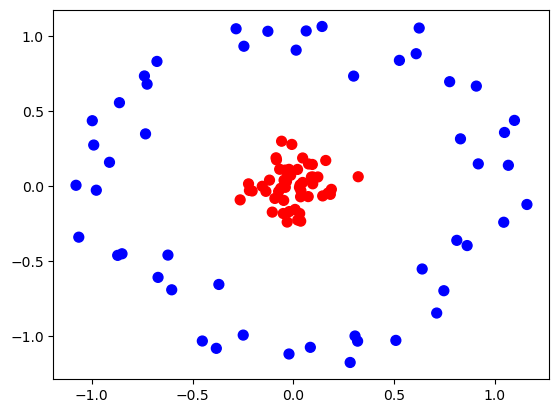

In [3]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [5]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.45

In [7]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_8884\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


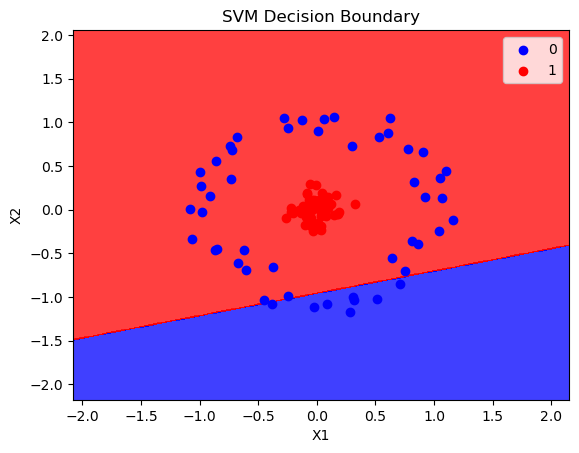

In [8]:
plot_decision_boundary(X, y, classifier)

In [10]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1)) # rbf kernel transformation (radial basis function)  to make data linearly separable in higher dimension
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

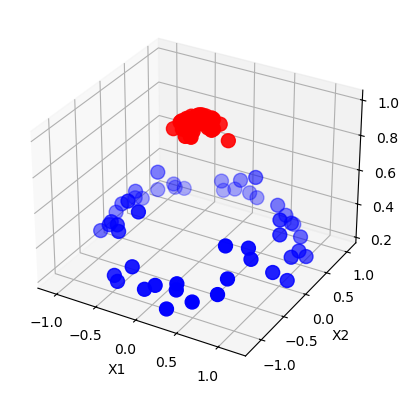

In [11]:
plot_3d_plot(X,y)

In [12]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [13]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\hp\AppData\Local\Temp\ipykernel_8884\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


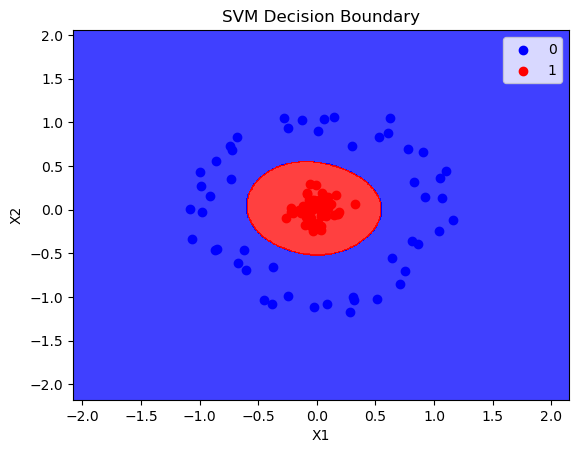

In [14]:
plot_decision_boundary(X, y, rbf_classifier)

In [15]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [16]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\hp\AppData\Local\Temp\ipykernel_8884\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


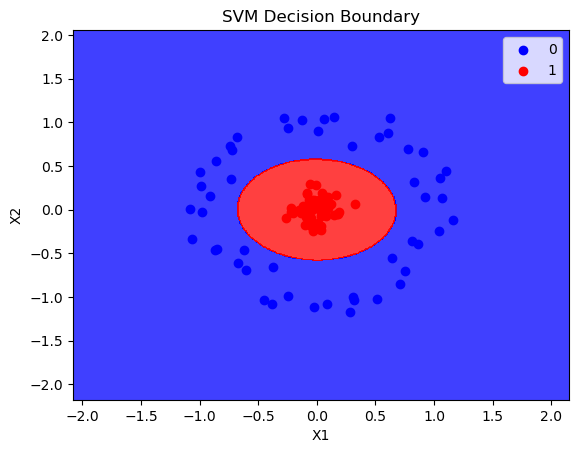

In [17]:
plot_decision_boundary(X, y, poly_classifier)

In [18]:
X

array([[ 0.01454229,  0.90473556],
       [ 0.18947888, -0.02253021],
       [ 0.28281462, -1.17558862],
       [ 1.04555012, -0.24153471],
       [ 0.03214254, -0.18337199],
       [ 0.52741557,  0.83665922],
       [ 0.62568221,  1.05204865],
       [ 0.09880571,  0.05946437],
       [ 0.83072553,  0.31395324],
       [-0.73897128,  0.7328047 ],
       [-0.012692  ,  0.07136475],
       [ 0.74813764, -0.69760962],
       [-0.87180876, -0.46212372],
       [ 0.03653179, -0.07198899],
       [-1.0787461 ,  0.00466973],
       [ 0.04680872,  0.18649958],
       [ 0.07617383,  0.1465891 ],
       [-0.04728662, -0.09604677],
       [-0.04048384,  0.10577535],
       [ 0.09042241,  0.05978324],
       [-0.07257843, -0.03663964],
       [-0.38190295, -1.08141956],
       [-0.15376082, -0.00197221],
       [ 0.00933268, -0.15616248],
       [ 0.1843305 , -0.05567422],
       [-0.72566611,  0.67826107],
       [ 0.61068167,  0.88096324],
       [ 0.31976959, -1.03359946],
       [ 0.90939197,

In [19]:
np.exp(-(X**2)).sum(1)

array([1.44086086, 1.96422711, 1.17420476, 1.27848077, 1.96590115,
       1.2537562 , 1.0066699 , 1.98675516, 1.40765876, 1.16371426,
       1.99475895, 1.18605127, 1.27534785, 1.99349731, 1.31230876,
       1.96362719, 1.97295521, 1.98858391, 1.98723633, 1.98828947,
       1.99340466, 1.17481947, 1.97663101, 1.97582114, 1.96349821,
       1.22187438, 1.14891101, 1.24638405, 1.07974792, 1.96838831,
       1.31312036, 1.99046163, 1.99590814, 1.95812814, 1.13495438,
       1.19720069, 1.32853483, 1.30302795, 1.30785815, 1.15992249,
       1.94931267, 1.99837278, 1.21316559, 1.31468746, 1.20978788,
       1.95291068, 1.21193635, 1.34010304, 1.52291183, 1.99895545,
       1.97445459, 1.16401685, 1.97065566, 1.9831571 , 1.39394005,
       1.95939928, 1.12526785, 1.94300416, 1.41030301, 1.47045016,
       1.92439029, 1.98948816, 1.97095815, 1.99724937, 1.38345636,
       1.4992073 , 1.2566772 , 1.99646745, 1.95815933, 1.9815662 ,
       1.91161219, 1.99797876, 1.98486578, 1.09037907, 1.99759

In [20]:

X_new=np.exp(-(X**2))

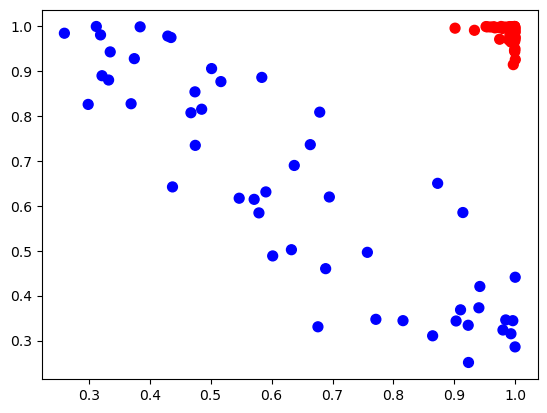

In [21]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')